In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
TELESCOPE_PARAMS = {
    "parkes": {
        "D": 64,
        "eta": 0.6,
        "Trec": 28,
        "Tsky": 3,
        "BW": 340e6,
        "nu_cen": 1.382e9,
        "n_comp": 16,
        "n_dishes": 1,
        "n_chan": int(1024*340/400),
        "mode": "multibeam",
        "n_beams": 13,
        "tsamp": 0.064,
        "fov": 0.56,
    },
    "fast": {
        "D": 300,
        "eta": 0.6,
        "Trec": 17,
        "Tsky": 3,
        "BW": 400e6,
        "nu_cen": 1.25e9,
        "n_chan": 2048,
        "n_comp": 8,
        "n_dishes": 1,
        "mode": "multibeam",
        "n_beams": 19,
        "tsamp": 196.608e-6,
        "fov": 0.061,
    },
    "meerkat_incoherent": {
        "D": 13.5,
        "eta": 0.70,
        "Trec": 20,
        "Tsky": 3,
        "BW": 856e6,
        "nu_cen": 1.284e9,
        "n_comp": 16,
        "n_dishes": 64,
        "n_chan": 2048,
        "mode": "incoherent",
        "description": "MeerKAT array - incoherent beam (power addition)",
        "tsamp": 306.24e-6,
        "fov": 1.27,
    },
    "meerkat_coherent": {
        "D": 13.5,
        "eta": 0.70,
        "Trec": 20,
        "Tsky": 3,
        "BW": 856e6,
        "nu_cen": 1.284e9,
        "n_comp": 16,
        "n_dishes": 40,
        "n_chan": 2048,
        "mode": "coherent",
        "description": "MeerKAT array - coherent beam (phase alignment)",
        "tsamp": 306.24e-6,
        "fov": 0.4,
    },
    "askap_ics": {
        "D": 12,
        "eta": 0.6,
        "Trec": 70,
        "Tsky": 3,
        "BW": 336e6,
        "nu_cen": 1.32e9,
        "n_comp": 16,
        "n_dishes": 36,
        "n_chan": 2048,
        "mode": "incoherent",
        "description": "ASKAP array - Incoherent configuration",
        "tsamp": 1.265e-3,
        "fov": 20,
    },
    "askap_flyeye": {
        "D": 12,
        "eta": 0.6,
        "Trec": 70,
        "Tsky": 3,
        "BW": 336e6,
        "nu_cen": 1.32e9,
        "n_comp": 16,
        "n_dishes": 36,
        "n_chan": 2048,
        "mode": "multibeam",
        "description": "ASKAP array - fly's eye configuration",
        "tsamp": 1.265e-3,
        "fov": 160,
    },
    "dsa-110": {
        "D": 4.65,
        "eta": 0.65,
        "Trec": 22,
        "Tsky": 3,
        "BW": 250e6,
        "nu_cen": 1.405e9,
        "n_comp": 9,
        "n_dishes": 48,
        "n_chan": 8192,
        "mode": "coherent",
        "description": "DSA-110 array - coherent beam",
        "tsamp": 262.144e-3,
        "fov": 10,
    },

    "apertif": {
        "D": 25,
        "eta": 0.65,
        "Trec": 70,
        "Tsky": 3,
        "BW": 300e6,
        "nu_cen": 1.37e9,
        "n_comp": 11,
        "n_dishes": 12,
        "n_chan": 1536,
        "mode": "coherent",
        "description": "Apertif array - coherent beam",
        "tsamp": 0.04096e-3,
        "fov": 8.2,
    },
}


ANTENNA GAIN (G0) RANKING - FROM SMALLEST TO LARGEST
         Telescope  D (m)  eta  n_dishes       Mode Gain Factor    G0 (K/Jy)
      ASKAP_FLYEYE  12.00 0.60        36  multibeam        1.00 2.458638e-02
         ASKAP_ICS  12.00 0.60        36 incoherent        6.00 1.475183e-01
           DSA-110   4.65 0.65        48   coherent       48.00 1.919735e-01
MEERKAT_INCOHERENT  13.50 0.70        64 incoherent        8.00 2.904266e-01
            PARKES  64.00 0.60         1  multibeam        1.00 6.993458e-01
           APERTIF  25.00 0.65        12   coherent       12.00 1.387252e+00
  MEERKAT_COHERENT  13.50 0.70        40   coherent       40.00 1.452133e+00
              FAST 300.00 0.60         1  multibeam        1.00 1.536649e+01


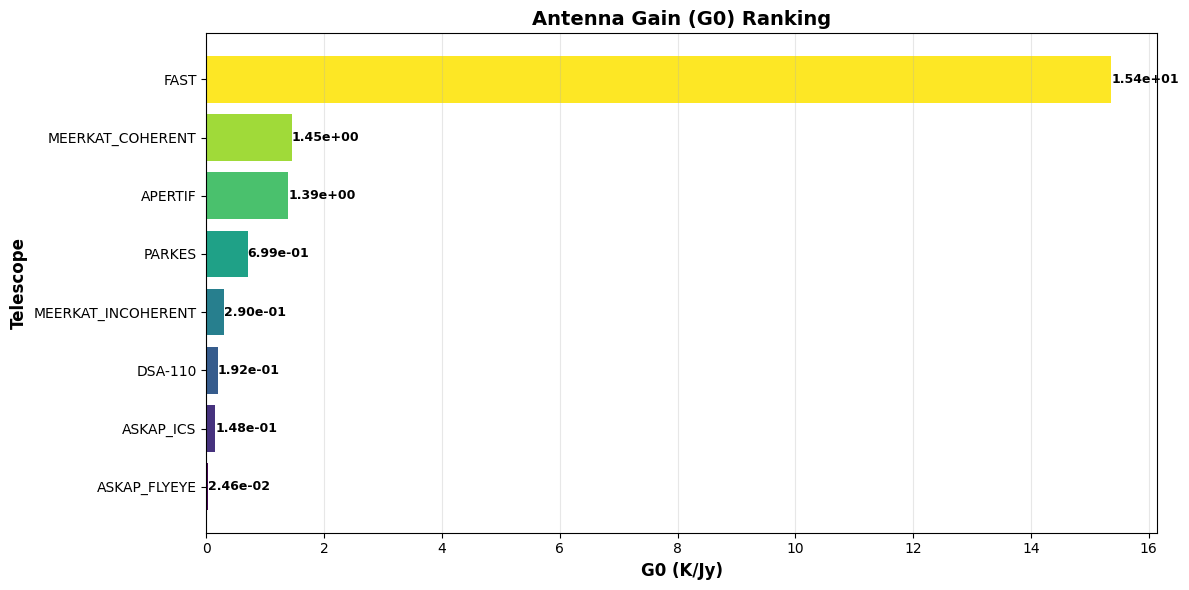


Key Insights:
  Highest G0 (Best): FAST = 1.54e+01 K/Jy
  Lowest G0 (Worst): ASKAP_FLYEYE = 2.46e-02 K/Jy
  Ratio (Best/Worst): 625.0x


In [4]:
# ============================================================================
# CALCULATE G0 FOR ALL TELESCOPES AND RANK
# ============================================================================

k = 1.38e-23  # Boltzmann constant (J/K)
c = 3.0e8     # Speed of light

results = []

for telescope_name, params in TELESCOPE_PARAMS.items():
    D = params["D"]
    eta = params["eta"]
    n_dishes = params.get("n_dishes", 1)
    mode = params.get("mode", "single")
    
    # Calculate array gain factor based on mode
    if mode == "coherent":
        array_gain_factor = n_dishes
    elif mode == "incoherent":
        array_gain_factor = np.sqrt(n_dishes)
    else:  # multibeam or single
        array_gain_factor = 1
    
    # Calculate G0 (in K/Jy)
    G0 = np.pi * D*D/4 * eta/2.0/k*1e-26 * array_gain_factor
    
    results.append({
        'Telescope': telescope_name.upper(),
        'D (m)': D,
        'eta': eta,
        'n_dishes': n_dishes,
        'Mode': mode,
        'Gain Factor': f"{array_gain_factor:.2f}",
        'G0 (K/Jy)': f"{G0:.6e}",
        'G0_numeric': G0  # For sorting
    })

# Sort by G0 (smallest to largest)
results_sorted = sorted(results, key=lambda x: x['G0_numeric'])

# Create DataFrame for display
df_results = pd.DataFrame(results_sorted)
df_display = df_results.drop('G0_numeric', axis=1)

print("\n" + "="*120)
print("ANTENNA GAIN (G0) RANKING - FROM SMALLEST TO LARGEST")
print("="*120)
print(df_display.to_string(index=False))
print("="*120)

# Plot ranking
fig, ax = plt.subplots(figsize=(12, 6))
names = [r['Telescope'] for r in results_sorted]
g0_values = [r['G0_numeric'] for r in results_sorted]
colors = plt.cm.viridis(np.linspace(0, 1, len(names)))

bars = ax.barh(names, g0_values, color=colors)
ax.set_xlabel('G0 (K/Jy)', fontsize=12, fontweight='bold')
ax.set_ylabel('Telescope', fontsize=12, fontweight='bold')
ax.set_title('Antenna Gain (G0) Ranking', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, g0_values)):
    ax.text(val, bar.get_y() + bar.get_height()/2, f'{val:.2e}', 
            va='center', ha='left', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print(f"  Highest G0 (Best): {results_sorted[-1]['Telescope']} = {results_sorted[-1]['G0_numeric']:.2e} K/Jy")
print(f"  Lowest G0 (Worst): {results_sorted[0]['Telescope']} = {results_sorted[0]['G0_numeric']:.2e} K/Jy")
print(f"  Ratio (Best/Worst): {results_sorted[-1]['G0_numeric'] / results_sorted[0]['G0_numeric']:.1f}x")


BEAM FWHM (FULL WIDTH AT HALF MAXIMUM) RANKING - FROM SMALLEST TO LARGEST (BEST TO WORST)
         Telescope  D (m) nu_cen (GHz) FWHM (arcsec) FWHM (arcmin)   FWHM (rad)
              FAST 300.00        1.250      201.3145        3.3552 9.760000e-04
            PARKES  64.00        1.382      853.5288       14.2255 4.138025e-03
           APERTIF  25.00        1.370     2204.1728       36.7362 1.068613e-02
MEERKAT_INCOHERENT  13.50        1.284     4355.1932       72.5866 2.111457e-02
  MEERKAT_COHERENT  13.50        1.284     4355.1932       72.5866 2.111457e-02
         ASKAP_ICS  12.00        1.320     4765.9671       79.4328 2.310606e-02
      ASKAP_FLYEYE  12.00        1.320     4765.9671       79.4328 2.310606e-02
           DSA-110   4.65        1.405    11555.1860      192.5864 5.602112e-02


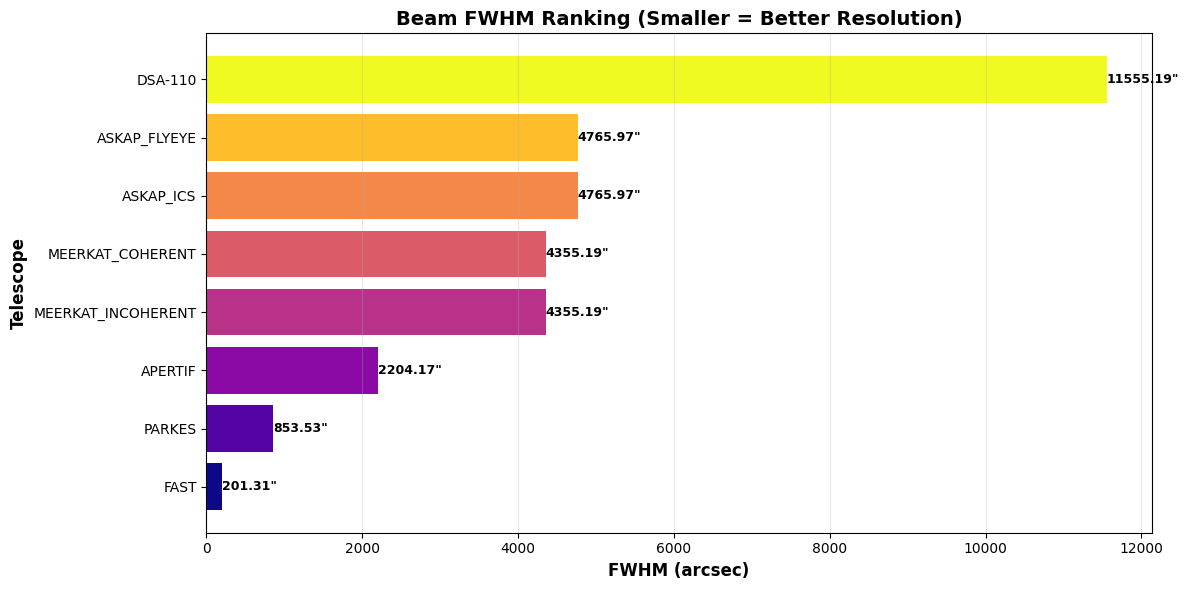


Key Insights:
  Best Resolution (Smallest FWHM): FAST = 201.3145 arcsec
  Worst Resolution (Largest FWHM): DSA-110 = 11555.1860 arcsec
  Ratio (Worst/Best): 57.4x


In [5]:
# ============================================================================
# CALCULATE FWHM FOR ALL TELESCOPES
# ============================================================================

k = 1.38e-23  # Boltzmann constant
c = 3.0e8     # Speed of light

results = []

for telescope_name, params in TELESCOPE_PARAMS.items():
    D = params["D"]
    nu_cen = params["nu_cen"]
    
    # Calculate wavelength at central frequency
    wavelength = c / nu_cen
    
    # Calculate FWHM (in radians): FWHM = 1.22 * λ / D
    fwhm_rad = 1.22 * wavelength / D
    
    # Convert to arcminutes
    fwhm_arcmin = fwhm_rad * (180.0 / np.pi) * 60.0
    
    # Convert to arcseconds
    fwhm_arcsec = fwhm_arcmin * 60.0
    
    results.append({
        'Telescope': telescope_name.upper(),
        'D (m)': D,
        'nu_cen (GHz)': f"{nu_cen/1e9:.3f}",
        'FWHM (arcsec)': f"{fwhm_arcsec:.4f}",
        'FWHM (arcmin)': f"{fwhm_arcmin:.4f}",
        'FWHM (rad)': f"{fwhm_rad:.6e}",
        'FWHM_numeric': fwhm_arcsec  # For sorting
    })

# Sort by FWHM (smallest to largest - best resolution)
results_sorted = sorted(results, key=lambda x: x['FWHM_numeric'])

# Create DataFrame for display
df_results = pd.DataFrame(results_sorted)
df_display = df_results.drop('FWHM_numeric', axis=1)

print("\n" + "="*130)
print("BEAM FWHM (FULL WIDTH AT HALF MAXIMUM) RANKING - FROM SMALLEST TO LARGEST (BEST TO WORST)")
print("="*130)
print(df_display.to_string(index=False))
print("="*130)

# Plot ranking
fig, ax = plt.subplots(figsize=(12, 6))
names = [r['Telescope'] for r in results_sorted]
fwhm_values = [r['FWHM_numeric'] for r in results_sorted]
colors = plt.cm.plasma(np.linspace(0, 1, len(names)))

bars = ax.barh(names, fwhm_values, color=colors)
ax.set_xlabel('FWHM (arcsec)', fontsize=12, fontweight='bold')
ax.set_ylabel('Telescope', fontsize=12, fontweight='bold')
ax.set_title('Beam FWHM Ranking (Smaller = Better Resolution)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, fwhm_values)):
    ax.text(val, bar.get_y() + bar.get_height()/2, f'{val:.2f}"', 
            va='center', ha='left', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print(f"  Best Resolution (Smallest FWHM): {results_sorted[0]['Telescope']} = {results_sorted[0]['FWHM_numeric']:.4f} arcsec")
print(f"  Worst Resolution (Largest FWHM): {results_sorted[-1]['Telescope']} = {results_sorted[-1]['FWHM_numeric']:.4f} arcsec")
print(f"  Ratio (Worst/Best): {results_sorted[-1]['FWHM_numeric'] / results_sorted[0]['FWHM_numeric']:.1f}x")


FOV CALCULATION BASED ON FWHM
         Telescope  D (m) FWHM (arcsec) FWHM (deg) FOV_Circular (deg²) FOV_Square (deg²) FOV_Provided (deg²)
            PARKES  64.00        853.53     0.2371                0.71              0.90                0.56
              FAST 300.00        201.31     0.0559                0.04              0.05                0.06
MEERKAT_INCOHERENT  13.50       4355.19     1.2098               18.39             23.42                1.27
  MEERKAT_COHERENT  13.50       4355.19     1.2098               18.39             23.42                0.40
         ASKAP_ICS  12.00       4765.97     1.3239               22.02             28.04               20.00
      ASKAP_FLYEYE  12.00       4765.97     1.3239               22.02             28.04              160.00
           DSA-110   4.65      11555.19     3.2098              129.47            164.84               10.00
           APERTIF  25.00       2204.17     0.6123                4.71              6.00         

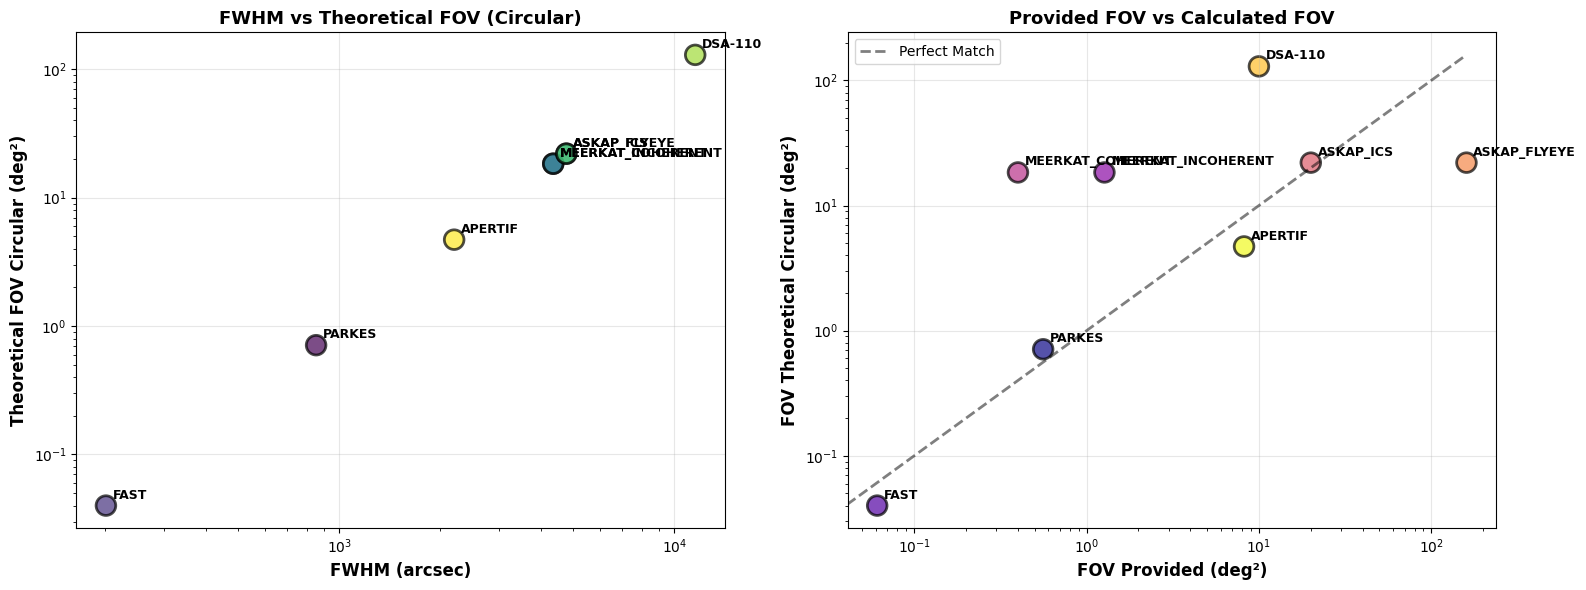


FOV RATIO: Provided / Theoretical Circular
PARKES               | Provided:     0.56 deg² | Theoretical:     0.71 deg² | Ratio:   0.79x
FAST                 | Provided:     0.06 deg² | Theoretical:     0.04 deg² | Ratio:   1.52x
MEERKAT_INCOHERENT   | Provided:     1.27 deg² | Theoretical:    18.39 deg² | Ratio:   0.07x
MEERKAT_COHERENT     | Provided:     0.40 deg² | Theoretical:    18.39 deg² | Ratio:   0.02x
ASKAP_ICS            | Provided:    20.00 deg² | Theoretical:    22.02 deg² | Ratio:   0.91x
ASKAP_FLYEYE         | Provided:   160.00 deg² | Theoretical:    22.02 deg² | Ratio:   7.27x
DSA-110              | Provided:    10.00 deg² | Theoretical:   129.47 deg² | Ratio:   0.08x
APERTIF              | Provided:     8.20 deg² | Theoretical:     4.71 deg² | Ratio:   1.74x


In [7]:
# ============================================================================
# CALCULATE FOV BASED ON FWHM
# ============================================================================

c = 3.0e8     # Speed of light

results = []

for telescope_name, params in TELESCOPE_PARAMS.items():
    D = params["D"]
    nu_cen = params["nu_cen"]
    fov_provided = params.get("fov", None)
    
    # Calculate wavelength at central frequency
    wavelength = c / nu_cen
    
    # Calculate FWHM (in radians): FWHM = 1.22 * λ / D
    fwhm_rad = 1.22 * wavelength / D
    fwhm_deg = fwhm_rad * (180.0 / np.pi)
    fwhm_arcsec = fwhm_deg * 3600.0
    
    # Calculate theoretical FOV from FWHM
    # Assuming circular beam with radius ~ 2 × FWHM (covers most of beam)
    radius_deg = 2.0 * fwhm_deg
    fov_theoretical_circular = np.pi * radius_deg**2  # circular area
    
    # For array systems, FOV might be different - use simple square approximation
    fov_theoretical_square = (4.0 * fwhm_deg)**2  # square area covering ±2 FWHM
    
    results.append({
        'Telescope': telescope_name.upper(),
        'D (m)': D,
        'FWHM (arcsec)': f"{fwhm_arcsec:.2f}",
        'FWHM (deg)': f"{fwhm_deg:.4f}",
        'FOV_Circular (deg²)': f"{fov_theoretical_circular:.2f}",
        'FOV_Square (deg²)': f"{fov_theoretical_square:.2f}",
        'FOV_Provided (deg²)': f"{fov_provided:.2f}" if fov_provided else "N/A",
        'FOV_provided_numeric': fov_provided
    })

# Create DataFrame for display
df_results = pd.DataFrame(results)
df_display = df_results.drop('FOV_provided_numeric', axis=1)

print("\n" + "="*160)
print("FOV CALCULATION BASED ON FWHM")
print("="*160)
print(df_display.to_string(index=False))
print("="*160)

print("\nNotes:")
print("  FOV_Circular: π × (2×FWHM)² - Circular area covering ~90% of beam power")
print("  FOV_Square: (4×FWHM)² - Square area covering ±2 FWHM in each direction")
print("  FOV_Provided: From telescope specifications")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Theoretical FOV vs FWHM relationship
ax = axes[0]
names = [r['Telescope'] for r in results]
fwhm_arcsec = [float(r['FWHM (arcsec)'].split()[0]) for r in results]
fov_circular = [float(r['FOV_Circular (deg²)'].split()[0]) for r in results]

scatter = ax.scatter(fwhm_arcsec, fov_circular, s=200, c=range(len(names)), cmap='viridis', alpha=0.7, edgecolors='black', linewidth=2)
for i, name in enumerate(names):
    ax.annotate(name, (fwhm_arcsec[i], fov_circular[i]), fontsize=9, fontweight='bold', 
               xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('FWHM (arcsec)', fontsize=12, fontweight='bold')
ax.set_ylabel('Theoretical FOV Circular (deg²)', fontsize=12, fontweight='bold')
ax.set_title('FWHM vs Theoretical FOV (Circular)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_yscale('log')

# Plot 2: Provided FOV vs Circular FOV
ax = axes[1]
fov_provided_vals = []
fov_circular_vals = []
names_valid = []

for r in results:
    if r['FOV_provided_numeric'] is not None:
        fov_provided_vals.append(r['FOV_provided_numeric'])
        fov_circular_vals.append(float(r['FOV_Circular (deg²)'].split()[0]))
        names_valid.append(r['Telescope'])

if fov_provided_vals:
    scatter = ax.scatter(fov_provided_vals, fov_circular_vals, s=200, c=range(len(names_valid)), 
                        cmap='plasma', alpha=0.7, edgecolors='black', linewidth=2)
    
    # Add diagonal line (perfect match)
    max_fov = max(max(fov_provided_vals), max(fov_circular_vals))
    ax.plot([0, max_fov], [0, max_fov], 'k--', linewidth=2, label='Perfect Match', alpha=0.5)
    
    for i, name in enumerate(names_valid):
        ax.annotate(name, (fov_provided_vals[i], fov_circular_vals[i]), fontsize=9, fontweight='bold',
                   xytext=(5, 5), textcoords='offset points')
    
    ax.set_xlabel('FOV Provided (deg²)', fontsize=12, fontweight='bold')
    ax.set_ylabel('FOV Theoretical Circular (deg²)', fontsize=12, fontweight='bold')
    ax.set_title('Provided FOV vs Calculated FOV', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xscale('log')
    ax.set_yscale('log')

plt.tight_layout()
plt.show()

# Print ratio comparison
print("\n" + "="*100)
print("FOV RATIO: Provided / Theoretical Circular")
print("="*100)
for r in results:
    if r['FOV_provided_numeric'] is not None:
        fov_circ = float(r['FOV_Circular (deg²)'].split()[0])
        ratio = r['FOV_provided_numeric'] / fov_circ if fov_circ > 0 else 0
        print(f"{r['Telescope']:20s} | Provided: {r['FOV_provided_numeric']:8.2f} deg² | "
              f"Theoretical: {fov_circ:8.2f} deg² | Ratio: {ratio:6.2f}x")